In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("calls.csv")

G = nx.from_pandas_edgelist(df, source="caller", target="callee", edge_attr="duration", create_using=nx.Graph())

In [3]:
degree_centrality = nx.degree_centrality(G)

In [4]:
values = list(degree_centrality.values())
high_threshold = np.percentile(values, 90)
low_threshold = np.percentile(values, 10)

hubs = [node for node, val in degree_centrality.items() if val >= high_threshold]
peripherals = [node for node, val in degree_centrality.items() if val <= low_threshold]

print("Hubs:", hubs)
print("Peripherals:", peripherals)

Hubs: [300, 301, 299, 401, 687, 681, 466, 225, 269, 470, 405, 578, 90, 474, 12, 13, 845, 374, 136, 288, 49, 342, 243, 491, 208, 207, 560, 688, 133, 424, 92, 221, 52, 96, 190, 677, 371, 492, 268, 4, 567, 441, 266, 36, 179, 372, 830, 572, 88, 176, 472, 344, 682, 444, 304, 551, 95, 395, 106, 173, 324, 657, 119, 254, 485, 672, 280, 244, 109, 37, 100, 69, 263, 262, 448, 3, 364, 743, 104, 220, 598, 180, 611, 15, 351, 499]
Peripherals: [574, 42, 222, 669, 546, 639, 89, 382, 514, 696, 306, 72, 73, 650, 24, 82, 121, 752, 622, 592, 623, 720, 714, 771, 337, 438, 652, 167, 21, 390, 788, 354, 585, 428, 206, 362, 391, 442, 435, 145, 554, 638, 214, 430, 335, 279, 569, 801, 163, 697, 202, 260, 709, 50, 212, 367, 199, 147, 228, 399, 469, 774, 539, 526, 473, 402, 504, 161, 292, 282, 671, 813, 200, 317, 538, 412, 564, 80, 345, 242, 56, 177, 346, 107, 120, 486, 285, 689, 489, 340, 707, 427, 164, 192, 203, 562, 102, 321, 271, 343, 17, 807, 799, 502, 66, 528, 571, 607, 334, 312, 94, 70, 553, 258, 215, 625, 

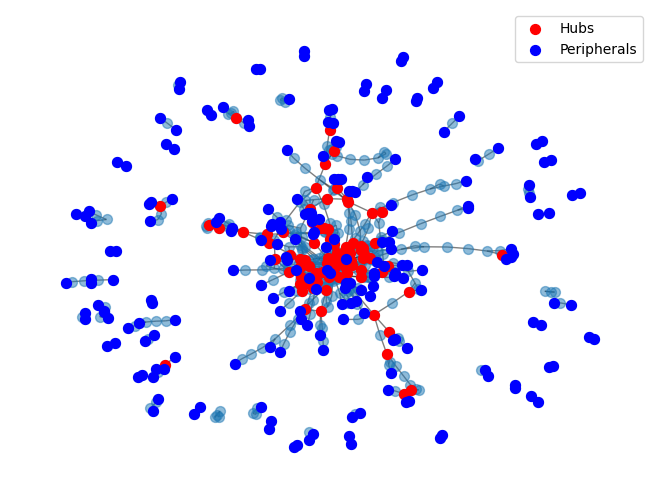

In [13]:
pos = nx.spring_layout(G)
nx.draw(G, pos, node_size=50, alpha=0.5)
nx.draw_networkx_nodes(G, pos, nodelist=hubs, node_color="red", node_size=50, label="Hubs")
nx.draw_networkx_nodes(G, pos, nodelist=peripherals, node_color="blue", node_size=50, label="Peripherals")
plt.legend()
plt.show()